### Implementing simple Chatbot Using LangGraph

In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [5]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-5.4")
llm.invoke("Hello")

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 7, 'total_tokens': 19, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05', 'system_fingerprint': None, 'id': 'chatcmpl-DfJ87XJveqmL4NZO03ai1jDd394U3', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e2502-13b2-74e1-88d7-733c88eaef9b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 12, 'total_tokens': 19, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [6]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="qwen/qwen3-32b")
llm_groq.invoke("Hey I am Valac and i like to play cricket")

AIMessage(content="<think>\nOkay, the user introduced himself as Valac and mentioned he likes to play cricket. I should respond warmly and show enthusiasm for his interests.\n\nFirst, I need to acknowledge his introduction and welcome him. Then, ask about his experience with cricket - maybe he's a player, a fan, or involved in some other way. This helps me understand how to engage further.\n\nCricket is a broad topic, so I should consider asking follow-up questions to find common ground. I could ask about his favorite aspect of the game, any favorite teams, or what position he plays if he plays. This helps steer the conversation towards shared interests.\n\nI should also consider if there are any cultural or regional aspects of cricket that might be relevant - different countries have different formats and traditions. But I don't want to assume anything, so it's better to ask open-ended questions first.\n\nI should keep the tone friendly and inviting, encouraging him to share more abou

### We Will start With Creating Nodes

In [7]:
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

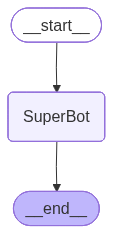

In [8]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile()


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [ ]:
## Invocation

graph_builder.invoke({'messages':"Hi,My name is Valac And I like Nier:Automata"})

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='a28ca34c-eada-478e-8ed8-ef3759447093'),
  AIMessage(content="Hello Krish! Nice to meet you. Cricket is a fantastic sport, isn't it? Do you enjoy playing cricket or are you more into watching the matches? Who is your favorite cricket player? Feel free to share more about what you like about the sport!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 39, 'total_tokens': 92, 'completion_time': 0.265, 'prompt_time': 0.004223914, 'queue_time': 0.236344133, 'total_time': 0.269223914}, 'model_name': 'qwen-2.5-32b', 'system_fingerprint': 'fp_35f92f8282', 'finish_reason': 'stop', 'logprobs': None}, id='run-a20669ad-74bd-440e-96f1-e368a5a9cdce-0', usage_metadata={'input_tokens': 39, 'output_tokens': 53, 'total_tokens': 92})]}

#### Streaming The responses

In [ ]:
for event in graph_builder.stream({"messages":"Hello My name is Valac"}):
    print(event)

{'SuperBot': {'messages': [AIMessage(content="Hello Krish! It's nice to meet you. How can I assist you today? Is there anything specific you would like to talk about or any questions you have?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 35, 'total_tokens': 69, 'completion_time': 0.17, 'prompt_time': 0.003981866, 'queue_time': 0.226247007, 'total_time': 0.173981866}, 'model_name': 'qwen-2.5-32b', 'system_fingerprint': 'fp_35f92f8282', 'finish_reason': 'stop', 'logprobs': None}, id='run-cb7964d1-a9df-477e-b016-539ee446c375-0', usage_metadata={'input_tokens': 35, 'output_tokens': 34, 'total_tokens': 69})]}}
